In [1]:
import torch
import torch.nn as nn
from torch.nn import functional as F
from typing import Optional, Tuple

import time

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [2]:
from datetime import datetime
def showTime():
    return str("["+datetime.now().strftime('%Y-%m-%d %H:%M:%S.%f')+" UTC]")

In [3]:
class Head(nn.Module):
    """A single self-attention head for a Transformer model with causal masking.

    This module processes input embeddings into query, key, and value vectors,
    computes scaled dot-product attention scores with causal masking to prevent 
    future context leakage, and outputs weighted value vectors.

    Attributes:
        key (nn.Linear): Projects input embeddings to key vectors of shape (head_size).
        query (nn.Linear): Projects input embeddings to query vectors of shape (head_size).
        value (nn.Linear): Projects input embeddings to value vectors of shape (head_size).
        tril (Tensor): Lower triangular mask buffer enforced during attention computation.
        dropout (nn.Dropout): Dropout layer applied post-softmax for regularization.
    """

    def __init__(self, n_embd: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the self-attention head.
        
        Args:
            n_embd (int): Input embedding dimension (must match input's last dimension).
            head_size (int): Dimensionality of key/query/value vectors (output size).
            block_size (int): Maximum sequence length for the causal mask buffer.
            dropout (float): Dropout probability for attention weights (0-1 range).
        """
        super().__init__()

        # [KEY, QUERY, VALUE LINEAR PROJECTIONS]
        # Linear layers project embeddings to lower-dimensional key/query/value spaces 
        # without bias terms (common in some Transformer architectures for simplicity)
        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # [CAUSAL MASK CREATION]
        # Creates a fixed triangular mask for enforcing sequential order dependencies
        # Lower triangular part (1s below and on the main diagonal) allows attention 
        # to current and previous positions only. Stored as a buffer, not a learnable parameter
        self.register_buffer('tril', torch.tril(torch.ones(block_size, block_size)))

        # [DROPOUT LAYER]
        # Reduces overfitting by randomly zeroing attention probabilities during training
        self.dropout = nn.Dropout(dropout)


    # x Tensor shape (batch_size, time_steps, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Perform self-attention computation on input tensor.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Output attention vectors of shape (B, T, head_size)
        """
        # --- DIMENSION UNPACKING ---
        # B=batch_size, T=sequence_length, C=embedding_dim
        B,T,C = x.shape

        # --- LINEAR PROJECTIONS ---
        # Project embeddings into query, key, and value spaces (all T x head_size matrices)
        k = self.key(x)    # (B, T, head_size) - projected key vectors
        q = self.query(x)  # (B, T, head_size) - projected query vectors


        # --- ATTENTION SCORE COMPUTATION ---
        # 1. Compute query-key dot product for all pairs (scaled to prevent softmax saturation)
        wei = q @ k.transpose(-2,-1) # (B, T, head_size) @ (B, head_size, T) => (B, T, T)
        scale_factor = (k.shape[-1])**-0.5 # sqrt(head_size) for stability
        wei_scaled = wei / scale_factor     # Scaling prevents extreme values

        # 2. Apply causal mask to enforce sequential order
        # Masking ensures position i can't attend to j > i (future tokens)
        # Crop mask to current sequence length T
        wei_scaled = wei_scaled.masked_fill(self.tril[:T, :T] == 0, float('-inf')) # mark upper triangle (forbidden)

        # 3. Softmax normalization to get probabilities
        # Large negative values (-inf) become zero after softmax
        att_weights = F.softmax(wei_scaled, dim=-1)  # (B, T, T)

        # 4. Apply dropout to attention probabilities
        # Dropout randomly nullifies connections for regularization
        att_weights_dropped = self.dropout(att_weights)
        
        # --- VALUE COMBINING ---
        # Project input to value vectors then combine using attention weights
        v = self.value(x)         # (B, T, head_size) - projected value vectors
        # Matrix multiplication (B, T, T) x (B, T, head_size) = (B, T, head_size)
        out = att_weights_dropped @ v  

        return out


class MultiHeadAttention(nn.Module):
    """MultiHeadAttention implements parallel self-attention for multiple heads to process inputs independently.

    This module combines the outputs of multiple attention heads (via concatenation) and applies 
    a linear projection to restore the original embedding dimensionality. It is designed for 
    sequential/casual attention (e.g., in language modeling) where each position attends only to previous tokens.

    Parameters:
        n_embd (int): Input embedding dimension (must match the last dimension of the input tensor).
        num_heads (int): Number of parallel self-attention heads.
        head_size (int): Dimensionality of key, query, and value vectors for each head.
        block_size (int): Maximum context length for positional masking (shared with all heads). 
        dropout (float): Dropout probability applied to attention weights (head levels) and output (post-projection).

    Attributes:
        heads (nn.ModuleList): List of self-attention heads responsible for parallel computations.
        proj (nn.Linear): Projects the concatenated head outputs back to the original embedding dimension.
        dropout (nn.Dropout): Regularization layer applied after the projection.
    """

    def __init__(self, n_embd: int, num_heads: int, head_size: int, block_size: int, dropout: float) -> None:
        """Initialize the multi-head attention module with parallel heads and projection layer.
        
        Args:
            n_embd (int): Input embedding dimension (input's last dimension).
            num_heads (int): Number of parallel attention heads.
            head_size (int): Dimension of each head's key/query/value vectors.
            block_size (int): Max context length for causal masking (used by each head).
            dropout (float): Dropout rate for attention weights and output (0-1 range).
        """
        super().__init__()
        # 1. Create parallel heads
        # Each head is initialized with identical parameters and structure
        self.heads = nn.ModuleList([Head(n_embd, head_size, block_size, dropout) for _ in range(num_heads)])

        # 2. Concatenation projection layer
        # Combines outputs from all heads into original embedding dimension
        # Total input dimension = head_size * num_heads (sum of all heads' outputs)
        # Output dimension = n_embd
        self.proj = nn.Linear(head_size * num_heads, n_embd)

        # 3. Dropout for regularization after projection
        self.dropout = nn.Dropout(dropout)
        
    # x input with shape (batch_size, seq_length, embedding_dim)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Process input through parallel heads and project output.
        
        Args:
            x (Tensor): Input embeddings tensor
            
        Returns:
            Tensor: Processed embeddings tensor (batch_size, seq_length, embedding_dim)
        """
        # Step 1: Compute attention outputs for each head in parallel
        # - Each head processes input tensor independently → outputs (B, T, head_size)
        # - Cropping example: For 3 heads → list [head1_output, head2_output, head3_output]
        # - Final concatenated shape before projection: (B, T, head_size * num_heads)
        outputs = [h(x) for h in self.heads]  # type: list[Tensor]
        concatenated = torch.cat(outputs, dim=-1)  # (B,T,F) -> (B,T,[h1,h1,h1,h1,h2,h2,h2,h2,h3,h3,h3,h3])
        # Shape after concatenation: (batch_size, T, head_size*num_heads)

        # TODO: check if needed, remove if not
        # Step 2: Linear projection to restore original embedding dimension
        projected = self.proj(concatenated) # Output shape: (batch_size, T, n_embd)

        # Step 3: Apply dropout regularization to final output
        output = self.dropout(projected)
        
        return output


class FeedForward(nn.Module):
    """A feed-forward neural network layer with bottleneck architecture for Transformer.

    This module performs a linear transformation followed by a non-linear activation, 
    then another linear projection back to the original dimension with optional dropout.

    Args:
        n_embd (int): Input and output embedding dimension (the blocks are designed to be residual).
        dropout (float): Dropout rate for regularization. 

    Attributes:
        net (nn.Sequential): A neural network sequence comprising:
            1. A linear layer expanding to 4x input dimension.
            2. ReLU activation for non-linearity.
            3. A linear layer projecting back to original dimension.
            4. Dropout for regularization.
    """
    def __init__(self, n_embd: int, dropout: float) -> None:
        super().__init__()
        # Feeds through a ReLU-activated bottleneck layer with 4x expansion
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),      # Expand input to 4x width
            nn.ReLU(),                          # Non-linear activation
            nn.Linear(4 * n_embd, n_embd),      # Back to input dimension
            nn.Dropout(dropout)                 # Regularization 
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass applying the feed-forward sequence.

        Args:
            x (Tensor): Input tensor of shape (batch_size, sequence_length, n_embd)
            
        Returns:
            Tensor: Output tensor with residual connection applied (same shape as input).
        """
        return self.net(x) # Directly applies the sequential network layers

    
class Block(nn.Module):
    """Transformer block combining self-attention and feed-forward layers with residual connections.

    Implements the core Transformer architecture with post-norm (normalization applied after residual connections). 

    Args:
        n_embd (int): Dimension of input embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length (required for causal masking).
        dropout (float): Dropout rate for attention and feed-forward layers.

    Attributes:
        sa (MultiHeadAttention): Multi-head self-attention layer with causal masking.
        ffwd (FeedForward): Feed-forward neural network subnet.
        ln1 (nn.LayerNorm): First layer normalization to stabilize training.
        ln2 (nn.LayerNorm): Second layer normalization after feed-forward layer.
    """
    
    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float) -> None:
        super().__init__()
        head_size = n_embd // n_head
        error_message = f"n_embd {n_embd} must be divisible by n_head {n_head}"
        assert head_size * n_head == n_embd, error_message

        self.sa = MultiHeadAttention(    # Initialize causal self-attention layer
            n_embd=n_embd,
            num_heads=n_head,
            head_size=head_size,
            block_size=block_size,
            dropout=dropout
        )
        self.ffwd = FeedForward(n_embd=n_embd, dropout=dropout)  # Feed-forward subnet
        self.ln1 = nn.LayerNorm(n_embd)         # Normalization after attention
        self.ln2 = nn.LayerNorm(n_embd)         # Normalization after feed-forward
  
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Execute Transformer block computation with post-norm architecture.

        Args:
            x (Tensor): Input tensor of shape [batch_size, sequence_length, n_embd]

        Steps:
            1. Self-Attention: Compute attention with residual and LayerNorm.
            2. Feed-Forward: Apply non-linear processing with residual and LayerNorm.
            
        Returns:
            Tensor: Transformer-block processed tensor (same shape as input).
        """
        # 1. Self-Attention sublayer
        y = self.sa(x)          # Compute multi-head attention
        x = self.ln1(x + y)     # Add residual connection + normalize

        # 2. Feed-Forward sublayer
        y = self.ffwd(x)        # Non-linear bottleneck
        x = self.ln2(x + y)     # Residual + normalization

        return x


class GPTLanguageModel(nn.Module):
    """A full autoregressive language model with multi-head self-attention and positional embeddings.
    
    This model combines token and positional embeddings with a sequence of self-attention blocks to predict the next token in a sequence.
    
    Attributes:
        vocab_size (int): Size of the token vocabulary.
        n_embd (int): Dimensionality of token and positional embeddings.
        n_head (int): Number of self-attention heads.
        block_size (int): Maximum context length the model can handle.
        n_layer (int): Number of transformer blocks in the network.
        device (str): Device for tensor operations ('cpu' or 'cuda').
        token_embedding_table (nn.Embedding): Maps tokens to embedding vectors.
        position_embedding_table (nn.Embedding): Encodes positional information up to block_size positions.
        blocks (nn.Sequential): Sequence of transformer blocks processing embeddings.
        ln_f (nn.LayerNorm): Final layer normalization after transformer blocks.
        lm_head (nn.Linear): Linear layer predicting next-token probabilities.
    """
    def __init__(
        self,
        vocab_size: int,
        n_embd: int,
        n_head: int,
        block_size: int,
        n_layer: int,
        dropout: float,
        device: str,
        ignore_index: int = -100
    ) -> None:
        """Initialize the GPT-style language model.
        
        Args:
            vocab_size (int): Number of unique tokens in the vocabulary.
            n_embd (int): Dimension of token and positional embeddings (output size of embeddings).
            n_head (int): Number of parallel attention heads.
            block_size (int): Maximum sequence length the model can process.
            n_layer (int): Number of transformer blocks in the neural network.
            dropout (float): Dropout probability applied in attention and feedforward layers.
            device (str): Execution device ('cuda' for GPU acceleration).
            ignore_index (int): Label value to ignore in loss calculation (default: -100).
        """
        super().__init__()
        self.ignore_index = ignore_index
        self.block_size = block_size
        self.device = device

        # Embedding layers map input indices to dense vectors
        self.token_embedding_table = nn.Embedding(vocab_size, n_embd)
        # how many indices of size n_enbd
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        # Sequential transformer blocks
        # how many decoder blocks running sequentially
        self.blocks = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout) 
            for _ in range(n_layer)
        ])

        # Final processing layers
        self.ln_f = nn.LayerNorm(n_embd) # Final layer normalization stabilizes training
        self.lm_head = nn.Linear(n_embd, vocab_size) # Predict next token probabilities

        # Initialize weights using standard transformer initialization strategy
        self.apply(self._init_weights)
        self.to(device) # Move all components to the specified device

    def _init_weights(self, module: nn.Module) -> None:
        """Initialize weights using heuristics from the original Transformer paper.
        
        Args:
            module (nn.Module): Module to be initialized (linear/embedding layers).
        """
        if isinstance(module, nn.Linear):
            # Weight initialization tailored for deep networks (Gaussian with σ=0.02)
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                # Bias terms initialized to zero as per best practices
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            # Embedding weights initialized with small random values
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    
    def forward(self, input_tokens: torch.Tensor, targets: Optional[torch.Tensor] = None) -> Tuple[torch.Tensor, Optional[torch.Tensor]]:
        """Compute logit predictions and optionally calculate loss.
        
        Args:
            input_tokens (Tensor): Input tensor of shape (batch_size, context_length)
            targets (Tensor, optional): Target tokens of shape (batch_size, context_length)
        
        Returns:
            logits (Tensor): Unnormalized token probabilities (batch_size, context_length, vocab_size)
            loss (Tensor, optional): Loss value for training if targets provided
        """
        # Batch size and current sequence length
        B,T = input_tokens.shape

        # 1. Token embeddings (B, T) → (B, T, C)
        # index and targets are both (B,T) tensor of integers
        tok_emb = self.token_embedding_table(input_tokens) # (B,T,C)

        # 2. Positional embeddings (T) → (T, C)
        # Create a range tensor up to current T (dynamic slicing for varying input lengths)
        tok_positions = torch.arange(T, device=self.device)
        pos_emb = self.position_embedding_table(tok_positions) # (T,C)

        # 3. Combine embeddings with element-wise addition → (B, T, C)
        x = tok_emb + pos_emb # (B,T,C)

        # 4. Pass through transformer blocks → (B, T, C)
        x = self.blocks(x) # (B,T,C)

        # 5. Final layer normalization → (B, T, C)
        x = self.ln_f(x) # (B,T,C)

        # 6. Compute next-token predictions → (B, T, vocab_size)
        logits = self.lm_head(x) # (B,T,vocab_size)

        # Loss calculation (only done during training)
        if targets is None:
            loss = None
        else:
            # Reshape to merge batch and time dimensions for cross-entropy (B*T, vocab_size)
            B,T,C = logits.shape
            logits_flat = logits.view(B*T, C)
            targets_flat  = targets.view(B*T)

            # Calculate cross-entropy loss ignoring padding tokens
            loss = F.cross_entropy(logits_flat, targets_flat , ignore_index=self.ignore_index)
            
        return logits, loss
   
    def generate(self, input_tokens: torch.Tensor, max_new_tokens: int) -> torch.Tensor:
        """Generate new tokens autoregressively using greedy sampling.
        
        Args:
            input_tokens (Tensor): Starting token sequence (B, T_0)
            max_new_tokens (int): Number of tokens to generate
        
        Returns:
            Tensor: Extended sequence including generated tokens (B, T_0 + max_new_tokens)
        """
        # index is (B,T) array of idices in the current context
        for _ in range(max_new_tokens):

            # Crop input to model's maximum context length
            cropped_input = input_tokens[:, -self.block_size:]

            # Get full logits and ignore loss (targets not provided)
            logits, _ = self(cropped_input)

            # Get next token predictions from last time-step's output
            # Shape narrowing (B, T, C) → (B, 1, C)
            logits = logits[:, -1, :] # becomes (B,C)

            # Convert logits to probabilities (axis=-1 ensures proper normalization)
            probs = F.softmax(logits, dim=-1) # (B,C)

            # Sample one token index from distribution
            next_token = torch.multinomial(probs, num_samples=1) # (B,1)

            # Extend the sequence with new prediction
            input_tokens = torch.cat((input_tokens, next_token), dim=1) # (B,T+1)

        return input_tokens
    
    def advanced_generation(self,
        input_tokens: torch.Tensor,
        max_new_tokens: int,
        temperature: float = 1.0,
        top_k: Optional[int] = None,
        top_p: Optional[float] = None
    ) -> torch.Tensor:
        """Generate tokens with advanced sampling strategies (temperature, nucleus, top-k).
        
        Args:
            input_tokens (Tensor): Initial tokens of shape (B, T)
            max_new_tokens (int): Maximum tokens to generate
            temperature (float): Controls randomness (1=default, 0→deterministic)
            top_k (int, optional): Keep only top K most probable tokens (None→disabled)
            top_p (float, optional): Keep smallest window ≥ cumulative prob mass p (None→disabled)
        
        Returns:
            Tensor: Generated sequence (B, T + max_new_tokens)
        """
        
        for _ in range(max_new_tokens):
            # Context window clipping
            cropped_input = input_tokens[:, -self.block_size:]

            # Get predictions without loss calculation
            logits, _ = self(cropped_input)

            # Only consider last predicted token
            next_logits = logits[:, -1, :] 

            # Temperature scaling controls exploration-exploitation tradeoff
            scaled_logits = next_logits / temperature

            # Apply top-k sampling (if requested)
            if top_k is not None:
                # Find top-k values and set others to -inf
                top_k_values, _ = torch.topk(scaled_logits, min(top_k, scaled_logits.size(-1)))
                mask = scaled_logits < top_k_values[:, [-1]]  # Broadcast comparison
                scaled_logits[mask] = -float("inf")

            # Convert to probabilities after any pre-processing
            probs = F.softmax(scaled_logits, dim=-1)

            # Apply nucleus (top-p) sampling (if requested)
            if top_p is not None:
                sorted_probs, sorted_indices = torch.sort(probs, descending=True)
                cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

                # Determine indices to mask by identifying positions exceeding p
                sorted_indices_to_remove = cumulative_probs > top_p

                # Shift mask to apply to the appropriate tokens (keeps min. prob mass p)
                sorted_indices_to_remove[..., 1:] = sorted_indices_to_remove[..., :-1].clone()
                sorted_indices_to_remove[..., 0] = 0
                indices_to_remove = torch.zeros_like(logits).scatter_(1, sorted_indices, sorted_indices_to_remove)

                # Set probabilities of removed tokens to zero and normalize
                probs[indices_to_remove] = 0.0
                probs = probs / probs.sum(dim=-1, keepdim=True)

            # Sample with controlled probability distribution
            next_token = torch.multinomial(probs, num_samples=1)

            # Extend sequence
            input_tokens = torch.cat((input_tokens, next_token), dim=1)

        return input_tokens  # Final expanded tensor

In [4]:
# Example usage test
vocab_size_test = 16394
embedding_size_test = 512
number_of_heads_test = 8
block_size_test = 1024
number_of_blocks_test = 1
dropout_test = 0.2
head_size_test = embedding_size_test // number_of_heads_test
device_test = 'cuda' if torch.cuda.is_available() else 'cpu'


model = GPTLanguageModel(
    vocab_size=vocab_size_test,
    n_embd=embedding_size_test,
    n_head=number_of_heads_test,
    block_size=block_size_test,
    n_layer=number_of_blocks_test,
    dropout=dropout_test,
    device=device_test
)

model_size = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model size: {model_size / 1e6:.2f}M parameters")

print(
    f"Model created with {embedding_size_test=}, {number_of_heads_test=}, head_size={embedding_size_test//number_of_heads_test}")

# Create dummy input
input_tokens = torch.randint(0, vocab_size_test, (2, 50), device=device_test)

# Test forward pass
# Use input as target for testing shape
logits, loss = model(input_tokens, targets=input_tokens)
if loss is not None:
    print("Loss:", loss.item())

# Test generation
print("Generating...")
# Start generation from first 10 tokens
generated_tokens = model.generate(input_tokens[:, :10], max_new_tokens=20)
print("Generated tokens shape:", generated_tokens.shape)
print("Generated sequence example (first batch):\n",
        generated_tokens[0].tolist())

# Test advanced generation
print("\nAdvanced Generating (top_k=5, temp=0.8)...")
generated_tokens_adv = model.advanced_generation(
    input_tokens[:, :10],
    max_new_tokens=20,
    temperature=0.8,
    top_k=10
)
print("Generated tokens shape (adv):", generated_tokens_adv.shape)
print("Generated sequence example (adv, first batch):\n",
        generated_tokens_adv[0].tolist())

Model size: 20.48M parameters
Model created with embedding_size_test=512, number_of_heads_test=8, head_size=64
Loss: 9.746918678283691
Generating...
Generated tokens shape: torch.Size([2, 30])
Generated sequence example (first batch):
 [1252, 8488, 6731, 4472, 6236, 5893, 5601, 4194, 1359, 14229, 7625, 1911, 13911, 15406, 5104, 13250, 3374, 11233, 10944, 12466, 4052, 3810, 12926, 52, 9767, 569, 8947, 3939, 13916, 2442]

Advanced Generating (top_k=5, temp=0.8)...
Generated tokens shape (adv): torch.Size([2, 30])
Generated sequence example (adv, first batch):
 [1252, 8488, 6731, 4472, 6236, 5893, 5601, 4194, 1359, 14229, 14936, 8105, 6346, 10673, 8857, 2607, 14368, 8715, 12026, 5542, 6336, 3103, 3182, 12758, 10259, 16321, 7358, 2814, 9857, 5511]


In [5]:
# load tokenizer

from minbpe import RegexTokenizer

tokenizer = RegexTokenizer()
tokenizer.load(model_file="output_v6/tokenizer/darija_tokenizer.model")

def get_vocab_size(tokenizer: RegexTokenizer) -> int:
    vocab = tokenizer.vocab
    special_tokens = tokenizer.special_tokens

    return len(vocab) + len(special_tokens)

print(get_vocab_size(tokenizer))

1034


In [6]:
# create an instance of GPTLanguageModel class

torch.manual_seed(1337)

block_size = 1024
n_embd = 384
n_head = 12
n_layer = 12
dropout = 0.2
batch_size = 8
vocab_size = get_vocab_size(tokenizer)
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model = GPTLanguageModel(
    vocab_size=vocab_size,
    block_size=block_size,
    n_embd=n_embd,
    n_head=n_head,
    n_layer=n_layer,
    dropout=dropout,
    device=device
).to(device)

print(sum(p.numel() for p in model.parameters())/1e6, 'M parameters')

15.375626 M parameters


In [7]:
# Load the encoded data as a memory mapped file object by using mmap_mode='r'

import numpy as np

data = np.load('output_v6/encoded_data/encoded_output_val_v3.npy', mmap_mode='r')
print(f"Data shape: {data.shape}")

Data shape: (1783047728,)


In [8]:
# Calculate the index for splitting the data, allocating 90% for training and the remaining 10% for validation.
split_index = int(0.9*len(data))
split_index

1604742955

In [9]:
# The get_batch_for_loss_estimation is used to get a random batch from any split of the data.


def get_batch_for_loss_estimation(split: str) -> Tuple[torch.Tensor, torch.Tensor]:
    if split == 'train':
        start_index = 0
        end_index = split_index
    else:
        start_index = split_index
        end_index = len(data)

    available_blocks = (end_index - start_index - 1) // block_size
    block_indices = torch.randint(0, available_blocks, (batch_size,))

    x_batch, y_batch = [], []
    for i in block_indices:
        block_start = start_index + (i * block_size)
        x_batch.append(data[block_start:block_start+block_size])
        y_batch.append(data[block_start+1:block_start+block_size+1])

    x_batch = np.array(x_batch)
    y_batch = np.array(y_batch)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    return x_batch, y_batch

In [10]:
# The estimate_loss function is called periodically during training. 
# Given the large dataset size, evaluation is performed on 1000 batches. 
# Ideally, we would evaluate every batch in both the training and validation splits, 
# but this isn't feasible without powerful hardware.

from typing import Dict

@torch.no_grad()
def estimate_loss() -> Dict:
    output = {}
    eval_iters = 1000
    model.eval()
    for split in ["train", "val"]:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X,Y = get_batch_for_loss_estimation(split)
            with torch.autocast(device_type=device, dtype=torch.bfloat16):
                logits, loss = model(X, Y)
            losses[k] = loss.item()
        output[split] = losses.mean()
    model.train()
    
    return output

In [11]:
# save_checkpoint is used to save the model's weights and other data.
def save_checkpoint(
    model: GPTLanguageModel,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    loss: float,
    file_path: str = "checkpoint.pth"
) -> None:
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss
    }
    torch.save(checkpoint, file_path)

In [12]:
# Non-Overlapping batches
from tqdm import tqdm

torch.set_float32_matmul_precision('high')

gradient_accumulation_steps = 8
eval_interval = 1000
save_interval = 10000

# Calculate the number of complete non-overlapping blocks
non_overlapping_blocks = (split_index - 1) // block_size
total_batches = non_overlapping_blocks // batch_size

learning_rate = 3e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

batches_processed = 0
train_losses, val_losses = [], []
optimizer.zero_grad(set_to_none=True)

In [13]:
model_time_stamp = int(time.time())

import os
pre_training_dir = f"output_v6/pre_training/run_{model_time_stamp}"
if not os.path.exists(pre_training_dir):
    os.makedirs(pre_training_dir)
    print(f"{showTime()} Created: {pre_training_dir}")

# training loop
t0 = time.time()
for i in tqdm(
    iterable=range(0, non_overlapping_blocks, batch_size),
    desc="Processing",
    total=total_batches
):
    # Load a batch of non-overlapping blocks
    x_batch, y_batch = [], []
    for j in range(batch_size):
        if i+j < non_overlapping_blocks:
            block_start = (i+j) * block_size
            x = data[block_start:block_start+block_size]
            y = data[block_start+1:block_start+block_size+1]
            x_batch.append(x)
            y_batch.append(y)

    if len(x_batch) == 0:
        continue

    x_batch = np.array(x_batch)
    y_batch = np.array(y_batch)

    x_batch = torch.tensor(x_batch, dtype=torch.long).to(device)
    y_batch = torch.tensor(y_batch, dtype=torch.long).to(device)

    # Forward pass
    with torch.autocast(device_type=device, dtype=torch.bfloat16):
        logits, loss = model(x_batch, y_batch)
        loss /= gradient_accumulation_steps
    loss.backward()

    # Gradient accumulation
    batches_processed += 1
    if batches_processed % gradient_accumulation_steps == 0:
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)

    # Evaluate the model
    if batches_processed % eval_interval == 0:
        losses = estimate_loss()
        # timing and logging
        t1 = time.time()
        dt = t1 - t0
        t0 = t1
        print(f"{showTime()} Batch {batches_processed}: | train loss: {losses['train']: <7.4f} | val loss: {losses['val']: <7.4f} | time {dt*1000:.2f}ms")
        train_losses.append(losses['train'])
        val_losses.append(losses['val'])

        # generate from the model
        input_tokens = tokenizer.encode("I like apple juice, I drink it")
        input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)
        model.eval()
        with torch.no_grad():
            output = model.generate(input_tokens=input_tokens, max_new_tokens=100)
        print(tokenizer.decode(output[0].tolist()))
        model.train()

    # Save the model
    if batches_processed % save_interval == 0:
        output_file_path = os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
        save_checkpoint(
            model=model,
            optimizer=optimizer,
            epoch=batches_processed,
            loss=loss.item(),
            file_path=os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
        )

if batches_processed % gradient_accumulation_steps != 0:
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

save_checkpoint(
    model=model,
    optimizer=optimizer,
    epoch=batches_processed,
    loss=loss.item(),
    file_path=os.path.join(pre_training_dir, f"checkpoint_{batches_processed}.pth")
)

[2025-04-29 18:28:48.422901 UTC] Created: output_v6/pre_training/run_1745944128


Processing:   1%|          | 999/195891 [09:40<31:10:06,  1.74it/s]

[2025-04-29 18:46:08.828460 UTC] Batch 1000: | train loss: 4.7236  | val loss: 4.7425  | time 1040405.56ms


Processing:   1%|          | 1000/195891 [17:23<7540:09:22, 139.28s/it]

I like apple juice, I drink it their lld, in him and theyut whole joer

cistrose byn was fewon fets to also scay tored I know to get ro

S of the sipped by the).-"Rropselfat on MicialLgh admiew of the mcess one of mowerlygruming ration said acals them. whichpre of you there of the founds, teams


...

[2025-04-29 21:30:18.428866 UTC] Batch 11000: | train loss: 3.9213  | val loss: 3.9383  | time 852801.23ms


Processing:   6%|▌         | 11000/195891 [3:01:33<6083:21:30, 118.45s/it]

I like apple juice, I drink it fatcome as a contestable isn’t doesn’t want to be ground out comparts in the fanies in the psylacy home incrae. Nowntopely play that meant about.

As50 computlt their jobs areashens us medious weled into hostbled25-13.



1000-rans so facture, they h


Processing:   6%|▌         | 11348/195891 [3:04:06<49:53:57,  1.03it/s]   


KeyboardInterrupt: 

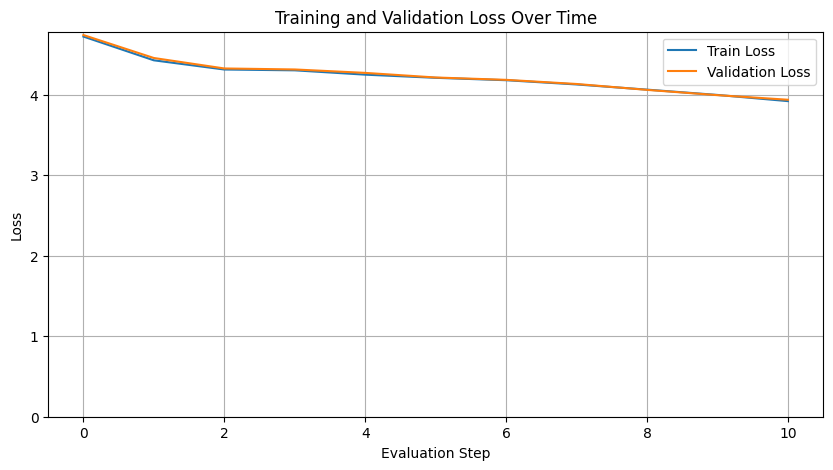

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Evaluation Step")
plt.ylim(0)
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Time")
plt.legend()
plt.grid()
plt.show()

In [17]:
# generate from the model
input_tokens = tokenizer.encode("I like apple juice - I drink it")
input_tokens = torch.tensor(input_tokens, dtype=torch.long).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model.generate(input_tokens=input_tokens, max_new_tokens=100)

print(tokenizer.decode(output[0].tolist()))

I like apple juice - I drink it feeling to bold time wasn, but the fighly or I ambtes to cover and seamily here. Bub as she just like his draw and he said it's only people missing to play by due his. “Now was on Mich had not to somehost two darkness, and bat senverr doesn't get my thive-onied, but when here, and he said
